# Revenue Management Analysis – Hotel Booking Demand

## Business Objective

The goal of this project is to analyze booking and demand patterns
from a revenue management perspective.

The analysis focuses on identifying factors associated with demand,
occupancy, cancellations and booking behavior. The long-term objective
is to determine whether booking patterns can be used to identify
potentially weak demand early enough to support revenue management
decisions such as targeted discounts or other demand-stimulating
measures.

## Data Dictionary

The dataset contains 119,390 hotel booking records from a City Hotel and a Resort Hotel. Each row represents a hotel reservation. The variable definitions below are based on the original dataset documentation.

| Variable                         | Description                                                                                                                   |
| -------------------------------- | ----------------------------------------------------------------------------------------------------------------------------- |
| `hotel`                          | Type of hotel: `City Hotel` or `Resort Hotel`.                                                                                |
| `is_canceled`                    | Indicates whether the booking was canceled: `1` = canceled, `0` = not canceled.                                               |
| `lead_time`                      | Number of days between the booking being entered into the hotel PMS and the arrival date.                                     |
| `arrival_date_year`              | Year of the arrival date.                                                                                                     |
| `arrival_date_month`             | Month of the arrival date.                                                                                                    |
| `arrival_date_week_number`       | Week number of the arrival date.                                                                                              |
| `arrival_date_day_of_month`      | Day of the month of the arrival date.                                                                                         |
| `stays_in_weekend_nights`        | Number of weekend nights booked or stayed.                                                                                    |
| `stays_in_week_nights`           | Number of weekday nights booked or stayed.                                                                                    |
| `adults`                         | Number of adults included in the booking.                                                                                     |
| `children`                       | Number of children included in the booking.                                                                                   |
| `babies`                         | Number of babies included in the booking.                                                                                     |
| `meal`                           | Type of meal package included in the booking.                                                                                 |
| `country`                        | Country of origin of the guest, represented using ISO country codes.                                                          |
| `market_segment`                 | Market segment associated with the booking.                                                                                   |
| `distribution_channel`           | Booking distribution channel. For example, `TA` = Travel Agents and `TO` = Tour Operators.                                    |
| `is_repeated_guest`              | Indicates whether the booking was made by a returning guest: `1` = repeated guest, `0` = not repeated guest.                  |
| `previous_cancellations`         | Number of previous bookings that were canceled by the customer.                                                               |
| `previous_bookings_not_canceled` | Number of previous bookings that were not canceled by the customer.                                                           |
| `reserved_room_type`             | Code of the room type originally reserved.                                                                                    |
| `assigned_room_type`             | Code of the room type ultimately assigned. This may differ from the reserved room type.                                       |
| `booking_changes`                | Number of changes or amendments made to the booking.                                                                          |
| `deposit_type`                   | Type of deposit/payment guarantee associated with the booking.                                                                |
| `agent`                          | ID of the travel agency that made the booking.                                                                                |
| `company`                        | ID of the company or entity that made the booking or was responsible for paying it.                                           |
| `days_in_waiting_list`           | Number of days the booking remained on the waiting list before being confirmed or canceled.                                   |
| `customer_type`                  | Type of booking/customer: `Contract`, `Group`, `Transient`, or `Transient-Party`.                                             |
| `adr`                            | Average Daily Rate: average lodging revenue per occupied room night, calculated from lodging transactions and staying nights. |
| `required_car_parking_spaces`    | Number of car parking spaces required by the guest.                                                                           |
| `total_of_special_requests`      | Number of special requests made by the guest.                                                                                 |
| `reservation_status`             | Final status of the reservation, e.g. `Check-Out`, `Canceled`, or `No-Show`.                                                  |
| `reservation_status_date`        | Date on which the reservation status was last updated.                                                                        |

**Note:** `agent` and `company` are identifiers rather than numerical measures. Although they are stored as numeric values in the CSV, they should be treated as categorical IDs when relevant to the analysis.

**Source:** Hotel Booking Demand dataset by Antonio, Almeida and Nunes; dataset documentation and Kaggle distribution.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../hotel_bookings.csv")

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df.shape

(119390, 32)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [6]:
df.columns.tolist()

['hotel',
 'is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'assigned_room_type',
 'booking_changes',
 'deposit_type',
 'agent',
 'company',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'reservation_status',
 'reservation_status_date']

In [7]:
df.isna().sum().sort_values(ascending=False)

company                           112593
agent                              16340
country                              488
children                               4
arrival_date_month                     0
arrival_date_week_number               0
hotel                                  0
is_canceled                            0
stays_in_weekend_nights                0
arrival_date_day_of_month              0
adults                                 0
stays_in_week_nights                   0
babies                                 0
meal                                   0
lead_time                              0
arrival_date_year                      0
distribution_channel                   0
market_segment                         0
previous_bookings_not_canceled         0
is_repeated_guest                      0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
previous_cancellations                 0
deposit_type    

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [9]:
df[df["adr"] <= 0][["hotel", "adr", "adults", "children", "babies", "stays_in_weekend_nights", "stays_in_week_nights", "is_canceled"]]

,hotel,adr,adults,children,babies,stays_in_weekend_nights,stays_in_week_nights,is_canceled
0,Resort Hotel,0.0,2,0.0,0,0,0,0
1,Resort Hotel,0.0,2,0.0,0,0,0,0
125,Resort Hotel,0.0,4,0.0,0,0,1,0
167,Resort Hotel,0.0,2,0.0,0,0,0,0
168,Resort Hotel,0.0,1,0.0,0,0,0,0
...,...,...,...,...,...,...,...,...
118631,City Hotel,0.0,1,0.0,0,0,0,0
118762,City Hotel,0.0,2,1.0,0,0,1,0
118963,City Hotel,0.0,2,0.0,0,0,0,0
119102,City Hotel,0.0,1,0.0,0,2,1,0


In [10]:
df[df["adr"] <= 0][["hotel", "adr", "adults", "children", "babies", "stays_in_weekend_nights", "stays_in_week_nights", "is_canceled"]]


,hotel,adr,adults,children,babies,stays_in_weekend_nights,stays_in_week_nights,is_canceled
0,Resort Hotel,0.0,2,0.0,0,0,0,0
1,Resort Hotel,0.0,2,0.0,0,0,0,0
125,Resort Hotel,0.0,4,0.0,0,0,1,0
167,Resort Hotel,0.0,2,0.0,0,0,0,0
168,Resort Hotel,0.0,1,0.0,0,0,0,0
...,...,...,...,...,...,...,...,...
118631,City Hotel,0.0,1,0.0,0,0,0,0
118762,City Hotel,0.0,2,1.0,0,0,1,0
118963,City Hotel,0.0,2,0.0,0,0,0,0
119102,City Hotel,0.0,1,0.0,0,2,1,0


In [11]:
df["adr"].value_counts().loc[lambda x: x.index <= 0]

adr
 0.00    1959
-6.38       1
Name: count, dtype: int64

In [12]:
df[df["adr"] < 0][[
    "hotel", "adr", "lead_time", "adults", "children", "babies",
    "stays_in_weekend_nights", "stays_in_week_nights",
    "is_canceled", "reservation_status"
]]

,hotel,adr,lead_time,adults,children,babies,stays_in_weekend_nights,stays_in_week_nights,is_canceled,reservation_status
14969,Resort Hotel,-6.38,195,2,0.0,0,4,6,0,Check-Out


A negative ADR value was identified during data validation. Since a negative daily room rate is not economically meaningful, the observation is treated as an anomalous transaction and will be excluded from analyses involving ADR.

In [13]:
df[df["adr"] == 0][[
    "hotel",
    "lead_time",
    "adults",
    "children",
    "babies",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "is_canceled",
    "reservation_status"
]].describe()

,lead_time,adults,children,babies,stays_in_weekend_nights,stays_in_week_nights,is_canceled
count,1959.000000,1959.000000,1959.000000,1959.000000,1959.000000,1959.000000,1959.000000
mean,39.649821,1.602859,0.066871,0.012762,0.397141,1.244513,0.108729
std,81.551039,2.540683,0.321386,0.112273,1.023978,2.313291,0.311378
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,33.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000
max,737.000000,55.000000,3.000000,1.000000,14.000000,35.000000,1.000000


In [14]:
df[df["adr"] == 0][[
    "stays_in_weekend_nights",
    "stays_in_week_nights"
]].sum()

stays_in_weekend_nights     778
stays_in_week_nights       2438
dtype: int64

In [15]:
df[df["adr"] == 0]["market_segment"].value_counts()

market_segment
Complementary    680
Online TA        367
Offline TA/TO    332
Groups           252
Direct           240
Corporate         82
Aviation           6
Name: count, dtype: int64

ADR = 0 does not necessarily indicate erroneous data. A substantial share of zero-ADR bookings belongs to the Complementary market segment, while other zero-ADR bookings require further investigation.

In [16]:
df[df["adr"] == 0]["reservation_status"].value_counts()

reservation_status
Check-Out    1746
Canceled      187
No-Show        26
Name: count, dtype: int64

In [17]:
df[df["adr"] == 0]["hotel"].value_counts()

hotel
City Hotel      1208
Resort Hotel     751
Name: count, dtype: int64

Data quality finding: The dataset contains 1,959 bookings with an ADR of zero and one booking with a negative ADR. Zero ADR values are not necessarily erroneous, as many occur in complementary bookings and most have a Check-Out reservation status. Therefore, zero-ADR bookings are retained, while the negative ADR observation is treated as an anomaly for analyses involving ADR.

In [18]:
df["adults"].value_counts().sort_index()

adults
0       403
1     23027
2     89680
3      6202
4        62
5         2
6         1
10        1
20        2
26        5
27        2
40        1
50        1
55        1
Name: count, dtype: int64

In [19]:
df[df["adults"] == 0][["children", "babies"]].value_counts().sort_index()

children  babies
0.0       0         180
1.0       0           4
2.0       0         205
          1           3
3.0       0          11
Name: count, dtype: int64

In [20]:
df[(df["adults"] == 0) & (df["children"] == 0) & (df["babies"] == 0)][
    ["hotel", "is_canceled", "lead_time", "adr",
     "market_segment", "customer_type", "reservation_status"]
].head(20)

,hotel,is_canceled,lead_time,adr,market_segment,customer_type,reservation_status
2224,Resort Hotel,0,1,0.0,Corporate,Transient-Party,Check-Out
2409,Resort Hotel,0,0,0.0,Corporate,Transient,Check-Out
3181,Resort Hotel,0,36,0.0,Groups,Transient-Party,Check-Out
3684,Resort Hotel,0,165,0.0,Groups,Transient-Party,Check-Out
3708,Resort Hotel,0,165,0.0,Groups,Transient-Party,Check-Out
4127,Resort Hotel,1,0,0.0,Offline TA/TO,Transient,Canceled
9376,Resort Hotel,1,0,0.0,Offline TA/TO,Group,Canceled
31765,Resort Hotel,0,31,28.0,Direct,Transient,Check-Out
32029,Resort Hotel,0,4,0.0,Groups,Transient-Party,Check-Out
32827,Resort Hotel,0,46,0.0,Direct,Transient,Check-Out


In [21]:
df[(df["adults"] == 0) & (df["children"] == 0) & (df["babies"] == 0)][
    ["stays_in_weekend_nights", "stays_in_week_nights", "adr", "reservation_status"]
].describe()

,stays_in_weekend_nights,stays_in_week_nights,adr
count,180.000000,180.000000,180.000000
mean,1.288889,3.233333,10.456500
std,2.348157,5.608354,31.681635
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,1.000000,0.000000
75%,2.000000,4.000000,0.000000
max,16.000000,41.000000,200.000000


In [22]:
df["children"].value_counts(dropna=False).sort_index()

children
0.0     110796
1.0       4861
2.0       3652
3.0         76
10.0         1
NaN          4
Name: count, dtype: int64

In [23]:
df[df["children"].isna()][
    ["adults", "babies", "adr", "is_canceled", "reservation_status"]
]

,adults,babies,adr,is_canceled,reservation_status
40600,2,0,12.0,1,Canceled
40667,2,0,12.0,1,Canceled
40679,3,0,18.0,1,Canceled
41160,2,0,76.5,1,Canceled


In [24]:
df[df["children"] == 10][
    ["hotel", "adults", "children", "babies", "adr",
     "is_canceled", "reservation_status"]
     
]

,hotel,adults,children,babies,adr,is_canceled,reservation_status
328,Resort Hotel,2,10.0,0,133.16,1,No-Show


In [25]:
df["total_nights"] = (
    df["stays_in_weekend_nights"]
    + df["stays_in_week_nights"]
)

df["total_nights"].describe()

count    119390.000000
mean          3.427900
std           2.557439
min           0.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          69.000000
Name: total_nights, dtype: float64

In [26]:
df_clean = df.copy()

## Data Cleaning

In [27]:
df_clean["children"] = df_clean["children"].fillna(0)
df_clean["children"].isna().sum()

np.int64(0)

In [28]:
guest_count = (
    df_clean["adults"]
    + df_clean["children"]
    + df_clean["babies"]
)

df_clean = df_clean[guest_count > 0]
df_clean.shape

(119210, 33)

In [29]:
df_clean = df_clean[df_clean["adr"] >= 0]
df_clean.shape

(119209, 33)

In [30]:
df_clean.isna().sum().sort_values(ascending=False).head()

company        112441
agent           16280
country           478
hotel               0
is_canceled         0
dtype: int64

In [31]:
df_clean["is_canceled"].mean()

np.float64(0.37076898556317056)

In [32]:
df_clean.groupby("hotel")["is_canceled"].mean()

hotel
City Hotel      0.417859
Resort Hotel    0.277681
Name: is_canceled, dtype: float64

In [33]:
df_clean["arrival_date_month"].value_counts()

arrival_date_month
August       13861
July         12644
May          11780
October      11147
April        11078
June         10929
September    10500
March         9767
February      8052
November      6771
December      6759
January       5921
Name: count, dtype: int64

In [34]:
df_clean["total_nights"].sum()

np.int64(408433)

In [35]:
df_clean.groupby("arrival_date_month")["total_nights"].sum()

arrival_date_month
April        37299
August       53949
December     21817
February     24404
January      17546
July         49625
June         39087
March        33331
May          38609
November     21606
October      34825
September    36335
Name: total_nights, dtype: int64

In [36]:
months = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

In [37]:
df_clean["arrival_date_month"] = pd.Categorical(
    df_clean["arrival_date_month"],
    categories=months,
    ordered=True
)

In [38]:
monthly_demand = (
    df_clean.groupby("arrival_date_month", observed=True)["total_nights"]
    .sum()
)

monthly_demand

arrival_date_month
January      17546
February     24404
March        33331
April        37299
May          38609
June         39087
July         49625
August       53949
September    36335
October      34825
November     21606
December     21817
Name: total_nights, dtype: int64

In [39]:
df_clean.groupby(
    ["arrival_date_month", "hotel"],
    observed=True
)["total_nights"].sum()

arrival_date_month  hotel       
January             City Hotel      11174
                    Resort Hotel     6372
February            City Hotel      14774
                    Resort Hotel     9630
March               City Hotel      19587
                    Resort Hotel    13744
April               City Hotel      22753
                    Resort Hotel    14546
May                 City Hotel      23342
                    Resort Hotel    15267
June                City Hotel      22756
                    Resort Hotel    16331
July                City Hotel      25320
                    Resort Hotel    24305
August              City Hotel      28263
                    Resort Hotel    25686
September           City Hotel      20602
                    Resort Hotel    15733
October             City Hotel      20826
                    Resort Hotel    13999
November            City Hotel      12882
                    Resort Hotel     8724
December            City Hotel      13226
 

In [40]:
monthly_hotel_demand = (
    df_clean.groupby(
        ["arrival_date_month", "hotel"],
        observed=True
    )["total_nights"]
    .sum()
    .unstack()
)

monthly_hotel_demand

hotel,City Hotel,Resort Hotel
arrival_date_month,,
January,11174,6372
February,14774,9630
March,19587,13744
April,22753,14546
May,23342,15267
June,22756,16331
July,25320,24305
August,28263,25686
September,20602,15733


In [41]:
monthly_hotel_share = (
    monthly_hotel_demand
    .div(monthly_hotel_demand.sum())
    .mul(100)
)

monthly_hotel_share

hotel,City Hotel,Resort Hotel
arrival_date_month,,
January,4.744698,3.684771
February,6.273328,5.568792
March,8.317021,7.947816
April,9.661366,8.411593
May,9.911467,8.828530
June,9.662640,9.443815
July,10.751364,14.054982
August,12.001019,14.853581
September,8.748010,9.098006


In [42]:
df_clean["lead_time_bucket"] = pd.cut(
    df_clean["lead_time"],
    bins=[-1, 7, 30, 60, 90, 180, float("inf")],
    labels=["0-7", "8-30", "31-60", "61-90", "91-180", ">180"]
)

In [43]:
df_clean["lead_time_bucket"].value_counts().sort_index()

lead_time_bucket
0-7       19635
8-30      18945
31-60     16952
61-90     12577
91-180    26420
>180      24680
Name: count, dtype: int64

In [44]:
df_clean.groupby("lead_time_bucket", observed=True)["total_nights"].sum()

lead_time_bucket
0-7        39240
8-30       58419
31-60      58038
61-90      47207
91-180    107984
>180       97545
Name: total_nights, dtype: int64

In [45]:
df_clean.groupby(
    ["lead_time_bucket", "hotel"],
    observed=True
)["total_nights"].sum()

lead_time_bucket  hotel       
0-7               City Hotel      22583
                  Resort Hotel    16657
8-30              City Hotel      36772
                  Resort Hotel    21647
31-60             City Hotel      35883
                  Resort Hotel    22155
61-90             City Hotel      28782
                  Resort Hotel    18425
91-180            City Hotel      60978
                  Resort Hotel    47006
>180              City Hotel      50507
                  Resort Hotel    47038
Name: total_nights, dtype: int64

In [46]:
lead_time_hotel_share = (
    df_clean.groupby(
        ["lead_time_bucket", "hotel"],
        observed=True
    )["total_nights"]
    .sum()
    .unstack()
    .div(
        df_clean.groupby("hotel")["total_nights"].sum()
    )
    .mul(100)
)

lead_time_hotel_share

hotel,City Hotel,Resort Hotel
lead_time_bucket,,
0-7,9.589181,9.632333
8-30,15.614106,12.517927
31-60,15.236619,12.811690
61-90,12.221397,10.654723
91-180,25.892444,27.182411
>180,21.446254,27.200916


In [47]:
monthly_lead_time = (
    df_clean.groupby(
        ["arrival_date_month", "lead_time_bucket"],
        observed=True
    )["total_nights"]
    .sum()
)

monthly_lead_time

arrival_date_month  lead_time_bucket
January             0-7                 4327
                    8-30                4912
                    31-60               3517
                    61-90               1696
                    91-180              2273
                                        ... 
December            8-30                4560
                    31-60               4127
                    61-90               2570
                    91-180              4431
                    >180                3223
Name: total_nights, Length: 72, dtype: int64

In [48]:
monthly_lead_time.unstack()

lead_time_bucket,0-7,8-30,31-60,61-90,91-180,>180
arrival_date_month,,,,,,
January,4327,4912,3517,1696,2273,821
February,4740,7148,4848,2727,3807,1134
March,4070,5635,7368,5081,7488,3689
April,2761,4144,4838,7312,12501,5743
May,2772,4442,3226,4425,12994,10750
June,2143,3367,4096,2761,13586,13134
July,2200,4482,4764,4640,18850,14689
August,4307,5381,6327,5231,16750,15953
September,2841,4412,3939,4618,5640,14885


In [49]:
monthly_lead_time_share = (
    monthly_lead_time.unstack()
    .div(monthly_lead_time.unstack().sum(axis=1), axis=0)
    .mul(100)
)

monthly_lead_time_share.round(1)

lead_time_bucket,0-7,8-30,31-60,61-90,91-180,>180
arrival_date_month,,,,,,
January,24.7,28.0,20.0,9.7,13.0,4.7
February,19.4,29.3,19.9,11.2,15.6,4.6
March,12.2,16.9,22.1,15.2,22.5,11.1
April,7.4,11.1,13.0,19.6,33.5,15.4
May,7.2,11.5,8.4,11.5,33.7,27.8
June,5.5,8.6,10.5,7.1,34.8,33.6
July,4.4,9.0,9.6,9.4,38.0,29.6
August,8.0,10.0,11.7,9.7,31.0,29.6
September,7.8,12.1,10.8,12.7,15.5,41.0


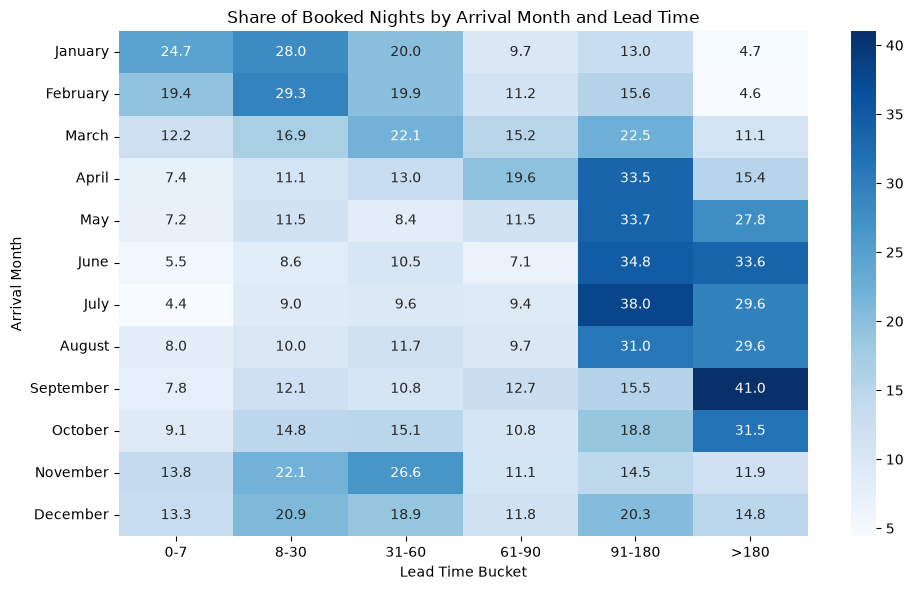

In [50]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    monthly_lead_time_share.round(1),
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Share of Booked Nights by Arrival Month and Lead Time")
plt.xlabel("Lead Time Bucket")
plt.ylabel("Arrival Month")
plt.tight_layout()
plt.show()

In [51]:
df_clean[["adr", "total_nights"]].corr()

,adr,total_nights
adr,1.00000,0.06981
total_nights,0.06981,1.00000


In [52]:
hotel_month = (
    df_clean.groupby(
        ["hotel", "arrival_date_month"],
        observed=True
    )
    .agg(
        demand=("total_nights", "sum"),
        avg_adr=("adr", "mean")
    )
)

hotel_month

demand     avg_adr
hotel        arrival_date_month                    
City Hotel   January              11174   82.754477
             February             14774   85.327519
             March                19587   92.973339
             April                22753  111.397415
             May                  23342  121.764614
             June                 22756  119.186056
             July                 25320  110.945950
             August               28263  114.857330
             September            20602  110.120296
             October              20826  100.119313
             November             12882   88.372486
             December             13226   89.209560
Resort Hotel January               6372   49.507033
             February              9630   55.189716
             March                13744   57.573834
             April                14546   77.849496
             May                  15267   78.758134
             June                 16331  110.481032
             July                 24305  155.181299
             August               25686  186.790574
             September            15733   93.252030
             October              13999   62.132572
             November              8724   48.313643
             December              8591   69.051887

In [53]:
hotel_month.groupby("hotel")["avg_adr"].agg(["min", "max", "mean"])

,min,max,mean
hotel,,,
City Hotel,82.754477,121.764614,102.252363
Resort Hotel,48.313643,186.790574,87.006771


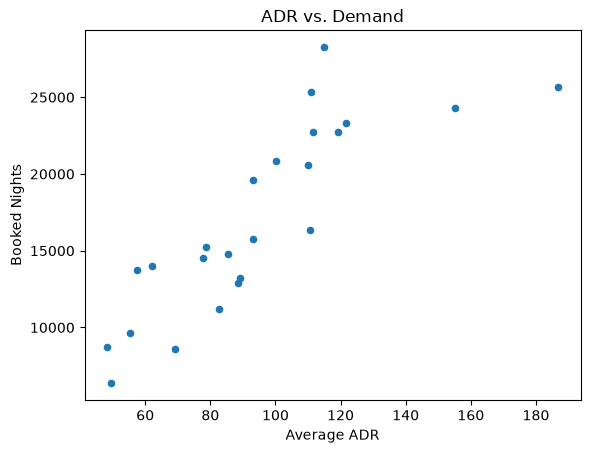

In [54]:
hotel_month.plot(
    x="avg_adr",
    y="demand",
    kind="scatter"
)

plt.title("ADR vs. Demand")
plt.xlabel("Average ADR")
plt.ylabel("Booked Nights")
plt.show()

In [55]:
hotel_month.sort_values("demand", ascending=False).head()

,,demand,avg_adr
hotel,arrival_date_month,,
City Hotel,August,28263,114.857330
Resort Hotel,August,25686,186.790574
City Hotel,July,25320,110.945950
Resort Hotel,July,24305,155.181299
City Hotel,May,23342,121.764614


In [57]:
hotel_month_revenue = (
    df_clean.assign(
        revenue_proxy=df_clean["adr"] * df_clean["total_nights"]
    )
    .groupby(
        ["hotel", "arrival_date_month"],
        observed=True
    )["revenue_proxy"]
    .sum()
)

hotel_month_revenue

hotel         arrival_date_month
City Hotel    January                955271.80
              February              1289304.88
              March                 1826498.99
              April                 2576523.49
              May                   2891311.78
              June                  2770012.03
              July                  2845594.97
              August                3289979.98
              September             2343070.28
              October               2121356.75
              November              1166441.42
              December              1195035.41
Resort Hotel  January                317417.97
              February               528793.05
              March                  812409.66
              April                 1133123.89
              May                   1216003.68
              June                  1728622.85
              July                  3741268.34
              August                4653066.85
              September    

In [58]:
monthly_booked_nights = monthly_demand

monthly_booked_nights_by_hotel = monthly_hotel_demand

monthly_booked_nights_share_by_hotel = monthly_hotel_share

monthly_booked_nights_by_month_and_lead_time = monthly_lead_time

monthly_booked_nights_share_by_month_and_lead_time = monthly_lead_time_share

lead_time_share_by_hotel = lead_time_hotel_share

monthly_demand_and_adr_by_hotel = hotel_month

monthly_revenue_proxy_by_hotel = hotel_month_revenue

In [62]:
revenue_per_booked_night_by_hotel = (
    monthly_revenue_proxy_by_hotel
    .unstack()
    .T
    .div(monthly_booked_nights_by_hotel)
)

revenue_per_booked_night_by_hotel

hotel,City Hotel,Resort Hotel
arrival_date_month,,
January,85.490585,49.814496
February,87.268504,54.911012
March,93.250574,59.110132
April,113.238847,77.899346
May,123.867354,79.649157
June,121.726667,105.849173
July,112.385267,153.929987
August,116.405901,181.151867
September,113.730234,88.231841


In [63]:
short_term_booked_nights = (
    df_clean.loc[
        df_clean["lead_time_bucket"].isin(["0-7", "8-30"]),
        "total_nights"
    ].sum()
)

short_term_booked_nights

np.int64(97659)

In [64]:
short_term_demand_share = (
    short_term_booked_nights
    / df_clean["total_nights"].sum()
    * 100
)

short_term_demand_share

np.float64(23.910653644539007)

23.91 % of hotel nights are booked short term (0-30 days prior).


In [65]:
short_term_booked_nights_by_hotel = (
    df_clean.loc[
        df_clean["lead_time_bucket"].isin(["0-7", "8-30"])
    ]
    .groupby("hotel")["total_nights"]
    .sum()
)

short_term_booked_nights_by_hotel

hotel
City Hotel      59355
Resort Hotel    38304
Name: total_nights, dtype: int64

In [66]:
short_term_demand_share_by_hotel = (
    short_term_booked_nights_by_hotel
    / df_clean.groupby("hotel")["total_nights"].sum()
    * 100
)

short_term_demand_share_by_hotel

hotel
City Hotel      25.203287
Resort Hotel    22.150259
Name: total_nights, dtype: float64

In [67]:
average_monthly_demand_by_hotel = (
    monthly_booked_nights_by_hotel
    .mean()
)

average_monthly_demand_by_hotel

hotel
City Hotel      19625.416667
Resort Hotel    14410.666667
dtype: float64

In [68]:
demand_index_by_hotel_and_month = (
    monthly_booked_nights_by_hotel
    .div(average_monthly_demand_by_hotel)
    * 100
)

demand_index_by_hotel_and_month

hotel,City Hotel,Resort Hotel
arrival_date_month,,
January,56.936371,44.217246
February,75.279930,66.825500
March,99.804250,95.373797
April,115.936392,100.939119
May,118.937602,105.942358
June,115.951678,113.325777
July,129.016369,168.659789
August,144.012229,178.242968
September,104.976115,109.176073


In [69]:
weak_demand_by_hotel_and_month = (
    demand_index_by_hotel_and_month < 80
)

weak_demand_by_hotel_and_month

hotel,City Hotel,Resort Hotel
arrival_date_month,,
January,True,True
February,True,True
March,False,False
April,False,False
May,False,False
June,False,False
July,False,False
August,False,False
September,False,False


In [70]:
demand_gap_by_hotel_and_month = (
    100 - demand_index_by_hotel_and_month
)

demand_gap_by_hotel_and_month

hotel,City Hotel,Resort Hotel
arrival_date_month,,
January,43.063629,55.782754
February,24.720070,33.174500
March,0.195750,4.626203
April,-15.936392,-0.939119
May,-18.937602,-5.942358
June,-15.951678,-13.325777
July,-29.016369,-68.659789
August,-44.012229,-78.242968
September,-4.976115,-9.176073


In [71]:
demand_gap_by_hotel_and_month.stack().sort_values(ascending=False)

arrival_date_month  hotel       
January             Resort Hotel    55.782754
                    City Hotel      43.063629
December            Resort Hotel    40.384437
November            Resort Hotel    39.461510
                    City Hotel      34.360629
February            Resort Hotel    33.174500
December            City Hotel      32.607800
February            City Hotel      24.720070
March               Resort Hotel     4.626203
October             Resort Hotel     2.856680
March               City Hotel       0.195750
April               Resort Hotel    -0.939119
September           City Hotel      -4.976115
May                 Resort Hotel    -5.942358
October             City Hotel      -6.117492
September           Resort Hotel    -9.176073
June                Resort Hotel   -13.325777
April               City Hotel     -15.936392
June                City Hotel     -15.951678
May                 City Hotel     -18.937602
July                City Hotel     -29.016369
A

In [72]:
weak_demand_flag_by_hotel_and_month = (
    demand_gap_by_hotel_and_month > 20
)

weak_demand_flag_by_hotel_and_month

hotel,City Hotel,Resort Hotel
arrival_date_month,,
January,True,True
February,True,True
March,False,False
April,False,False
May,False,False
June,False,False
July,False,False
August,False,False
September,False,False
